# 🎨 The Complete Seaborn Tutorial
### Statistical Data Visualization — From Foundations to Real-World EDA

## 👤 Author

**Name:** Muhammad Usman
**GitHub:** [@MuhammadUsman0005](https://github.com/MuhammadUsman0005)
**LinkedIn:** [@muhammad-usman-256364398](https://linkedin.com/in/muhammad-usman-256364398)

> **Library:** Seaborn 0.13.x
> **Difficulty:** Beginner → Advanced
> **Time to Complete:** ~3–4 hours

---

## 📚 Table of Contents

### PART 1 — Foundations
1. [Setup & The Style System](#setup) 🟢 MUST LEARN
2. [Distribution Plots — histplot & kdeplot](#dist) 🟢 MUST LEARN
3. [Scatter & Line Plots — Relationships](#relational) 🟢 MUST LEARN
4. [Categorical Plots — barplot & countplot](#categorical) 🟢 MUST LEARN

### PART 2 — Intermediate
5. [Box Plot & Violin Plot — Statistical Summaries](#box) 🟡 IMPORTANT
6. [Heatmap — Correlations & Confusion Matrices](#heatmap) 🟢 MUST LEARN
7. [Pairplot — Full EDA in One Line](#pairplot) 🟢 MUST LEARN
8. [Regression Plots — lmplot & regplot](#regression) 🟡 IMPORTANT

### PART 3 — Advanced & Practical
9. [FacetGrid — Conditional Subplots](#facet) 🟡 IMPORTANT
10. [Real-World EDA Workflow](#eda) 🟢 MUST LEARN
11. [Seaborn + Matplotlib — Fine-Tuning Plots](#combo) 🟢 MUST LEARN
12. [Key Takeaways & Cheat Sheet](#summary)

---

## Why Seaborn?

Seaborn sits on top of Matplotlib and does three things better:

1. **Statistical charts in one line** — `sns.pairplot(df)` gives you a full correlation grid that would take 30+ lines in Matplotlib
2. **Built-in dataset awareness** — pass a DataFrame and column names directly; Seaborn handles the rest
3. **Better defaults** — clean themes, smart color palettes, and automatic legend handling out of the box

**The key insight:** Seaborn is not a replacement for Matplotlib — it is Matplotlib with better defaults and statistical shortcuts. Every Seaborn plot is a Matplotlib `Axes` underneath, which means you can always drop into Matplotlib to customize anything further.

> **When to use Seaborn:** EDA, statistical analysis, ML evaluation plots, academic papers
> **When to use Matplotlib:** Custom dashboards, animation, pixel-level control


---
# PART 1 — Foundations
---

<a id='setup'></a>
## 1. Setup & The Style System

Seaborn's style system is one of its biggest advantages — a single function call transforms every plot in your session. Understanding it saves hours of manual rcParams tweaking.


In [1]:
# ─────────────────────────────────────────────────────────────
# IMPORTS — everything needed for this entire notebook
# ─────────────────────────────────────────────────────────────
import seaborn as sns            # main library — 'sns' is the universal alias
import matplotlib.pyplot as plt  # always needed for plt.show(), fig/ax access
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix  # for the heatmap section

%matplotlib inline

# ── Print versions so the notebook is reproducible ────────
print(f"Seaborn   : {sns.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Pandas    : {pd.__version__}")
print(f"NumPy     : {np.__version__}")


Seaborn   : 0.13.2
Matplotlib: 3.10.8
Pandas    : 3.0.2
NumPy     : 2.4.4


/tmp/ipykernel_614/1836518640.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


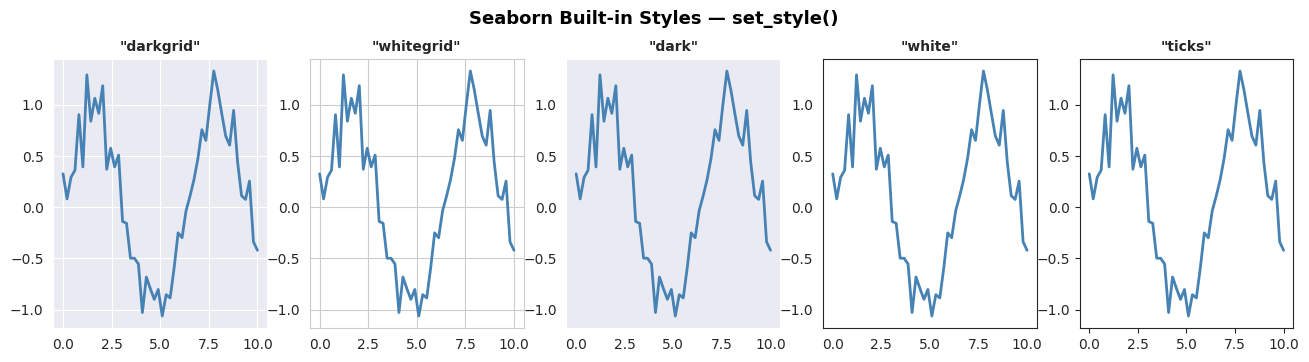

In [2]:
# ── The Style System — 3 independent controls ────────────────
#
# Seaborn separates visual style into three independent settings:
#
#   1. set_theme()  → master preset (combines style + context + palette)
#   2. set_style()  → background and grid type
#   3. set_context()→ font and element sizes (paper / notebook / talk / poster)
#
# You can use them individually or together.
# ─────────────────────────────────────────────────────────────

# ── Compare the 5 built-in styles ────────────────────────
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

np.random.seed(1)
x = np.linspace(0, 10, 50)
y = np.sin(x) + np.random.normal(0, 0.2, 50)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))

for ax, style in zip(axes, styles):
    with sns.axes_style(style):      # context manager — applies ONLY inside the block
        ax_ = fig.add_axes(ax.get_position())
        fig.delaxes(ax)
        sns.lineplot(x=x, y=y, ax=ax_, color='steelblue', linewidth=2)
        ax_.set_title(f'"{style}"', fontsize=10, fontweight='bold')
        ax_.set_xlabel('')
        ax_.set_ylabel('')

fig.suptitle('Seaborn Built-in Styles — set_style()', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


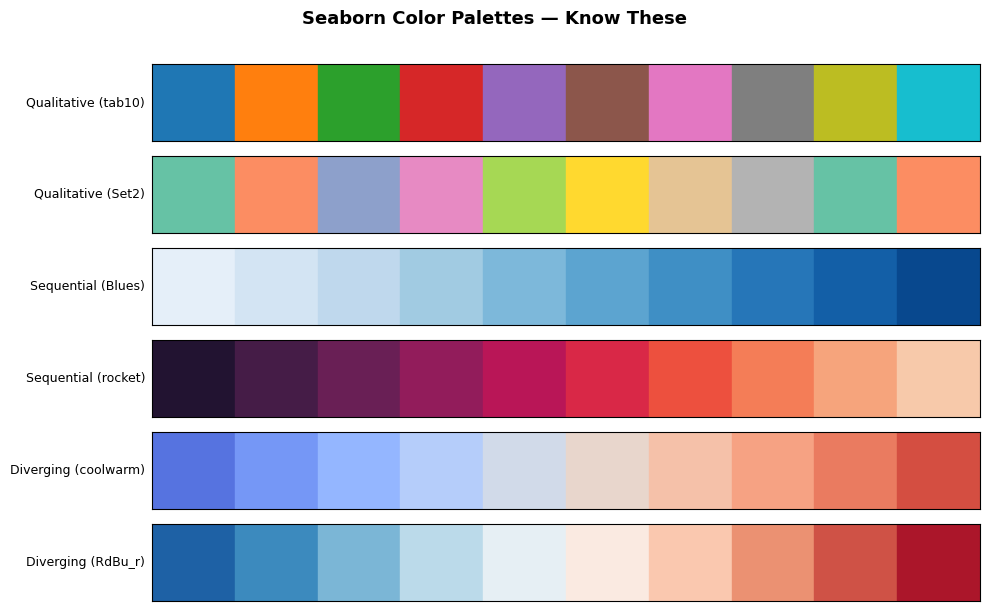

Global theme set — all plots below will use whitegrid + tab10.


In [3]:
# ── Color Palettes — the most important visual choice ─────────
#
# Seaborn has 3 types of palettes:
#   Qualitative  → distinct colors for categorical data  (tab10, Set2, husl)
#   Sequential   → light-to-dark for ordered data        (Blues, viridis, rocket)
#   Diverging    → two opposing colors around a midpoint (RdBu, coolwarm, vlag)
#
# sns.color_palette() returns a list of colors
# sns.set_palette()   applies a palette globally
# ─────────────────────────────────────────────────────────────

palettes = {
    'Qualitative (tab10)' : 'tab10',
    'Qualitative (Set2)'  : 'Set2',
    'Sequential (Blues)'  : 'Blues',
    'Sequential (rocket)' : 'rocket',
    'Diverging (coolwarm)': 'coolwarm',
    'Diverging (RdBu_r)'  : 'RdBu_r',
}

fig, axes = plt.subplots(len(palettes), 1, figsize=(10, 6))

for ax, (name, pal) in zip(axes, palettes.items()):
    colors = sns.color_palette(pal, 10)    # get 10 colors from the palette
    for i, color in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(name, fontsize=9, rotation=0, ha='right', va='center', labelpad=5)

fig.suptitle('Seaborn Color Palettes — Know These', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Set global theme for the REST of this notebook ────────
# This single call sets style + palette + font sizes
# All plots below will automatically inherit this theme
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
print("Global theme set — all plots below will use whitegrid + tab10.")


<a id='dist'></a>
## 2. Distribution Plots — histplot & kdeplot

Distribution plots answer: **"How are my values spread?"** They are the first thing you reach for during EDA when examining a numerical column.

| Function | Use |
|----------|-----|
| `sns.histplot()` | Histogram — count or density, optional KDE overlay |
| `sns.kdeplot()` | Smooth density curve — great for comparing groups |
| `sns.ecdfplot()` | Cumulative distribution — shows percentiles clearly |

> **In practice:** `histplot(kde=True)` covers 90% of real use cases. `kdeplot` shines when comparing multiple overlapping distributions.


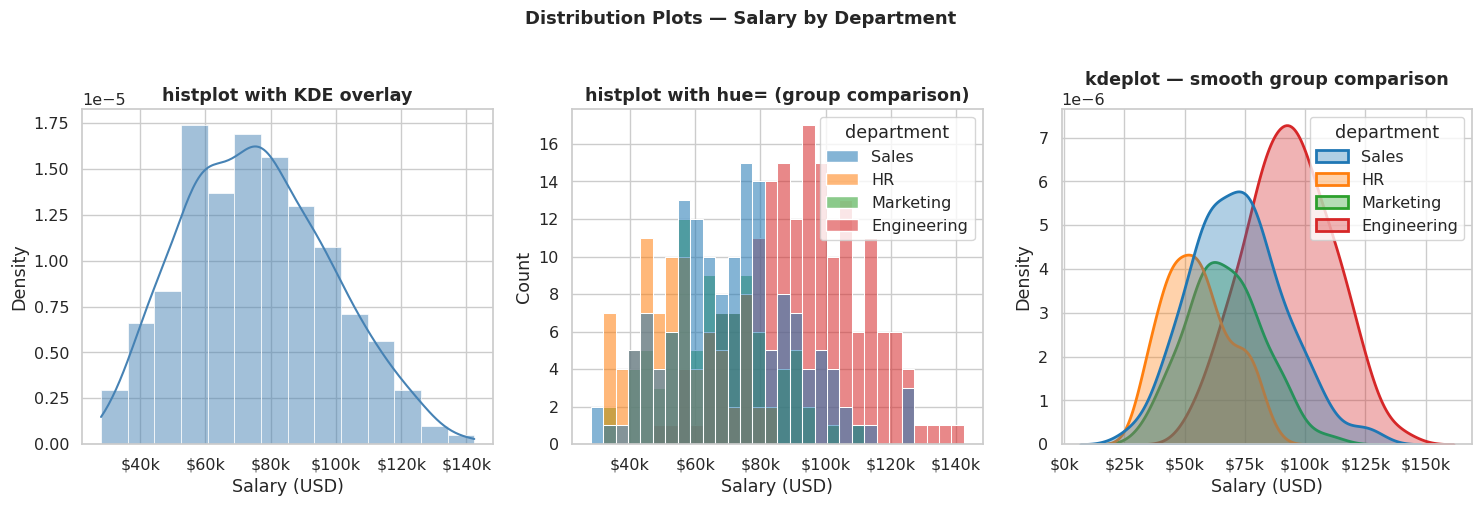

In [4]:
# ── Dataset: Employee salaries with department info ───────────
np.random.seed(42)
n = 500

departments = np.random.choice(['Engineering', 'Sales', 'Marketing', 'HR'], n,
                                p=[0.35, 0.30, 0.20, 0.15])

# Each department has a different salary distribution
salary_map = {
    'Engineering': lambda s: np.random.normal(95000, 18000, s),
    'Sales'      : lambda s: np.random.normal(70000, 22000, s),
    'Marketing'  : lambda s: np.random.normal(65000, 15000, s),
    'HR'         : lambda s: np.random.normal(55000, 12000, s),
}
salaries = np.array([salary_map[d](1)[0] for d in departments])
salaries = np.clip(salaries, 28000, 180000)

df_salary = pd.DataFrame({'salary': salaries, 'department': departments})

# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Plot 1: histplot with KDE overlay ─────────────────────
# kde=True adds a smooth density curve on top of the histogram
# stat='density' normalises y-axis to probability density (not count)
#   → use 'density' when you add kde=True for consistent y scale
sns.histplot(data=df_salary, x='salary',
             kde=True,            # overlay a kernel density estimate
             stat='density',      # y-axis = probability density
             color='steelblue',
             edgecolor='white',
             linewidth=0.5,
             ax=axes[0])
axes[0].set_title('histplot with KDE overlay', fontweight='bold')
axes[0].set_xlabel('Salary (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ── Plot 2: histplot with hue — compare groups ────────────
# hue= splits the data by a categorical column and draws each group
# in a different color — automatically adds a legend
# multiple='layer' overlaps the bars (use alpha for transparency)
sns.histplot(data=df_salary, x='salary', hue='department',
             multiple='layer',    # 'stack', 'dodge', 'fill', or 'layer'
             alpha=0.55,
             kde=False,
             bins=30,
             ax=axes[1])
axes[1].set_title('histplot with hue= (group comparison)', fontweight='bold')
axes[1].set_xlabel('Salary (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ── Plot 3: kdeplot — smooth curves, easier to compare ────
# kdeplot draws a smooth continuous density estimate.
# When comparing multiple groups, it is cleaner than overlapping histograms.
# fill=True shades the area under each curve
sns.kdeplot(data=df_salary, x='salary', hue='department',
            fill=True,        # shade under the curve
            alpha=0.35,       # transparency — essential when curves overlap
            linewidth=2,
            ax=axes[2])
axes[2].set_title('kdeplot — smooth group comparison', fontweight='bold')
axes[2].set_xlabel('Salary (USD)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

fig.suptitle('Distribution Plots — Salary by Department', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


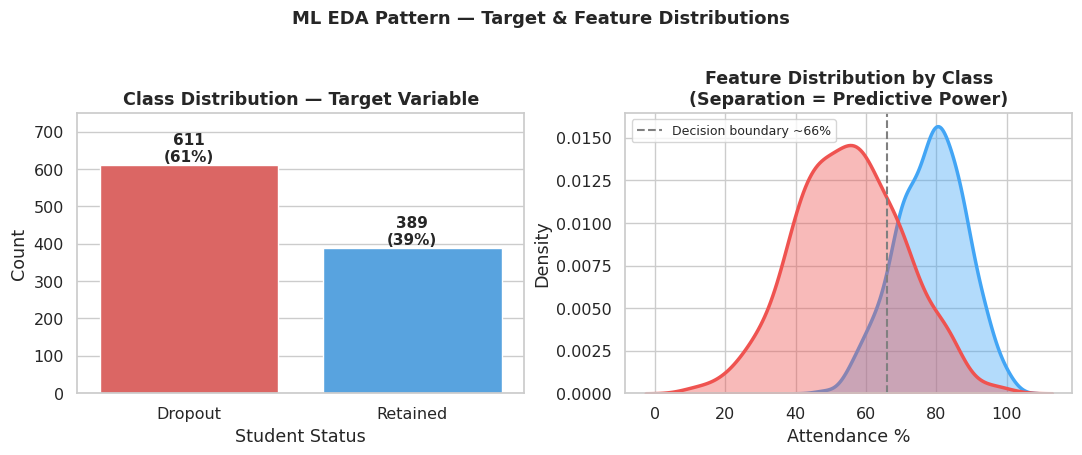

In [5]:
# ── Practical pattern: histplot for ML target variable check ──
# In any classification project, ALWAYS plot the target distribution first.
# This reveals class imbalance immediately — which affects model choice.

np.random.seed(7)
# Simulate a dropout dataset with class imbalance
dropout_labels = np.random.choice(['Dropout', 'Retained'], 1000,
                                   p=[0.60, 0.40])   # 60/40 imbalance

df_dropout = pd.DataFrame({'status': dropout_labels})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# ── countplot: counts of each category ────────────────────
# countplot is the categorical equivalent of a histogram
# It counts how many times each category appears
sns.countplot(data=df_dropout, x='status',
              hue='status',
              palette={'Dropout': '#EF5350', 'Retained': '#42A5F5'},
              edgecolor='white',
              legend=False,
              ax=ax1)

# Add count + percentage labels manually on top of each bar
total = len(df_dropout)
for patch in ax1.patches:
    count  = int(patch.get_height())
    pct    = count / total * 100
    ax1.text(patch.get_x() + patch.get_width()/2,
             patch.get_height() + 8,
             f'{count}\n({pct:.0f}%)',
             ha='center', fontsize=11, fontweight='bold')

ax1.set_title('Class Distribution — Target Variable', fontweight='bold')
ax1.set_xlabel('Student Status')
ax1.set_ylabel('Count')
ax1.set_ylim(0, 750)

# ── kdeplot for feature distribution split by class ───────
# This is the standard EDA pattern for binary classification:
# plot each feature's distribution split by the target class.
# Separation between the two curves = predictive power of that feature.
np.random.seed(3)
attendance_dropout  = np.random.normal(55, 15, 600)
attendance_retained = np.random.normal(78, 10, 400)
attendance_all = np.concatenate([attendance_dropout, attendance_retained])
label_all      = ['Dropout']*600 + ['Retained']*400
df_att = pd.DataFrame({'attendance': np.clip(attendance_all, 0, 100),
                       'status': label_all})

sns.kdeplot(data=df_att, x='attendance', hue='status',
            fill=True, alpha=0.4, linewidth=2.5,
            palette={'Dropout':'#EF5350','Retained':'#42A5F5'},
            ax=ax2)
ax2.set_title('Feature Distribution by Class\n(Separation = Predictive Power)',
              fontweight='bold')
ax2.set_xlabel('Attendance %')
ax2.axvline(66, color='gray', linestyle='--', linewidth=1.5,
            label='Decision boundary ~66%')
ax2.legend(fontsize=9)

fig.suptitle('ML EDA Pattern — Target & Feature Distributions',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<a id='relational'></a>
## 3. Scatter & Line Plots — Relationships

Seaborn's relational plots add a critical capability that plain Matplotlib scatter lacks: **encoding a third variable through `hue`, `size`, or `style`** — turning a 2D chart into a 3D or 4D visualization.

| Parameter | Encodes via |
|-----------|-------------|
| `hue=` | Color |
| `size=` | Marker size |
| `style=` | Marker shape |

All three can be used simultaneously — on the same plot, without any extra code.


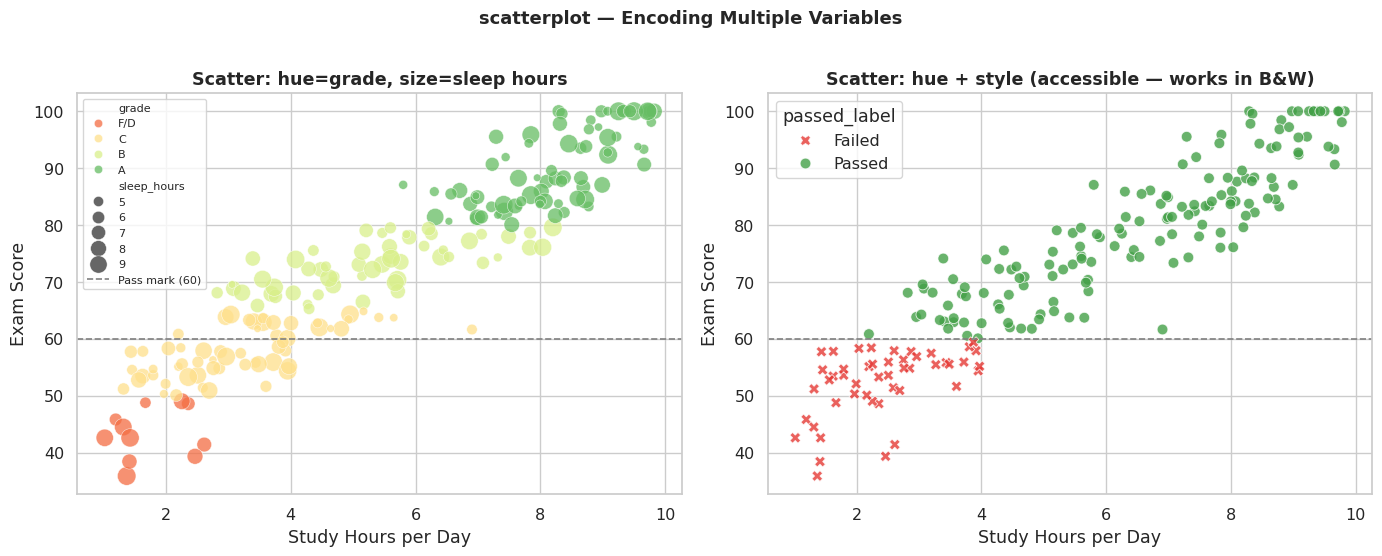

In [6]:
# ── Dataset: Student performance ─────────────────────────────
np.random.seed(21)
n = 200

study_hours  = np.random.uniform(1, 10, n)
exam_score   = 40 + 6*study_hours + np.random.normal(0, 6, n)
exam_score   = np.clip(exam_score, 0, 100)
sleep_hours  = np.random.uniform(4, 10, n)
passed       = (exam_score >= 60).astype(int)
grade        = pd.cut(exam_score, bins=[0,50,65,80,100],
                      labels=['F/D','C','B','A'])

df_students = pd.DataFrame({
    'study_hours' : study_hours,
    'exam_score'  : exam_score,
    'sleep_hours' : sleep_hours,
    'passed'      : passed,
    'grade'       : grade,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Plot 1: scatterplot with hue + size ───────────────────
# hue='grade'       → each grade gets a different color (auto legend)
# size='sleep_hours'→ marker size proportional to sleep hours
# sizes=(30, 180)   → pixel range for size mapping (min, max)
sns.scatterplot(data=df_students,
                x='study_hours',
                y='exam_score',
                hue='grade',                   # categorical → distinct colors
                size='sleep_hours',            # numerical → size scale
                sizes=(30, 180),
                alpha=0.75,
                palette='RdYlGn',             # Red=fail, Green=pass feels intuitive
                edgecolor='white',
                linewidth=0.4,
                ax=axes[0])

axes[0].set_title('Scatter: hue=grade, size=sleep hours',
                  fontweight='bold')
axes[0].set_xlabel('Study Hours per Day')
axes[0].set_ylabel('Exam Score')
axes[0].axhline(60, color='gray', linestyle='--', linewidth=1.2,
                label='Pass mark (60)')
axes[0].legend(fontsize=8, title_fontsize=9, loc='upper left')

# ── Plot 2: scatterplot with hue + style ──────────────────
# style= encodes a variable through MARKER SHAPE
# Combined with hue, it makes the plot readable in black & white too
# (important for academic papers that may be printed)
df_students['passed_label'] = df_students['passed'].map({1:'Passed', 0:'Failed'})

sns.scatterplot(data=df_students,
                x='study_hours',
                y='exam_score',
                hue='passed_label',
                style='passed_label',          # circle=Passed, X=Failed
                palette={'Passed':'#43A047', 'Failed':'#E53935'},
                markers={'Passed':'o', 'Failed':'X'},
                s=60,
                alpha=0.80,
                ax=axes[1])

axes[1].set_title('Scatter: hue + style (accessible — works in B&W)',
                  fontweight='bold')
axes[1].set_xlabel('Study Hours per Day')
axes[1].set_ylabel('Exam Score')
axes[1].axhline(60, color='gray', linestyle='--', linewidth=1.2)

fig.suptitle('scatterplot — Encoding Multiple Variables',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


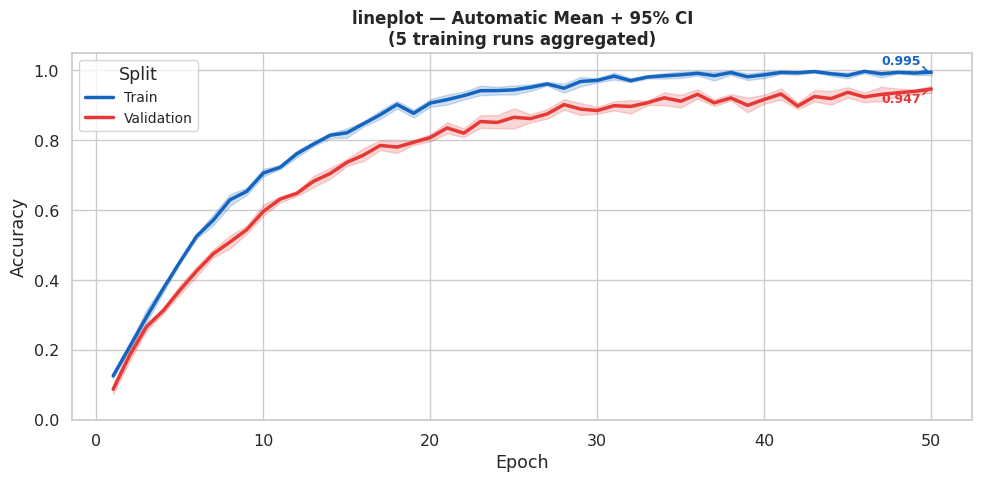

In [7]:
# ── lineplot — time series with automatic confidence interval ──
# This is where Seaborn's lineplot truly shines over Matplotlib.
# When you pass MULTIPLE y-values for the same x (multiple observations),
# Seaborn automatically:
#   1. Computes the MEAN at each x point
#   2. Draws a 95% confidence interval band around it
# In Matplotlib you'd need 15+ lines to do this manually.

np.random.seed(5)
epochs = np.arange(1, 51)

# 5 independent training runs (rows) × 50 epochs (columns)
n_runs  = 5
acc_runs = []
for run in range(n_runs):
    noise = np.random.normal(0, 0.015, 50)
    acc   = 1 - np.exp(-0.12 * epochs) + noise
    acc_runs.append(pd.DataFrame({
        'epoch'    : epochs,
        'accuracy' : np.clip(acc, 0, 1),
        'run'      : run + 1
    }))

df_training = pd.concat(acc_runs, ignore_index=True)

# Also make a val accuracy (slightly lower)
val_runs = []
for run in range(n_runs):
    noise = np.random.normal(0, 0.02, 50)
    acc   = 0.94 * (1 - np.exp(-0.1 * epochs)) + noise
    val_runs.append(pd.DataFrame({
        'epoch'    : epochs,
        'accuracy' : np.clip(acc, 0, 1),
        'run'      : run + 1
    }))
df_val = pd.concat(val_runs, ignore_index=True)

# Combine into one long-format DataFrame with a 'split' column
df_training['split'] = 'Train'
df_val['split']      = 'Validation'
df_curves = pd.concat([df_training, df_val], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))

# ── Seaborn computes mean + CI band automatically ─────────
# estimator='mean' (default) → draws the mean line
# errorbar='ci'   (default) → draws 95% confidence interval
# All 5 runs are aggregated — no manual np.mean() needed
sns.lineplot(data=df_curves,
             x='epoch',
             y='accuracy',
             hue='split',
             estimator='mean',       # aggregate function across runs
             errorbar=('ci', 95),    # confidence interval width
             linewidth=2.5,
             palette={'Train':'#1565C0', 'Validation':'#E53935'},
             ax=ax)

ax.set_title('lineplot — Automatic Mean + 95% CI\n(5 training runs aggregated)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.legend(title='Split', fontsize=10)

# Annotate final values
for split, color in [('Train','#1565C0'), ('Validation','#E53935')]:
    final = df_curves[df_curves['split']==split].groupby('epoch')['accuracy'].mean().iloc[-1]
    ax.annotate(f'{final:.3f}',
                xy=(50, final),
                xytext=(47, final + (0.02 if split=='Train' else -0.04)),
                fontsize=9, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

plt.tight_layout()
plt.show()


<a id='categorical'></a>
## 4. Categorical Plots — barplot & countplot

Seaborn's `barplot` shows the **mean** of a numerical variable for each category — with an error bar for the confidence interval. This is different from a histogram and different from a simple bar chart.

| Function | Shows |
|----------|-------|
| `countplot` | How many rows per category |
| `barplot` | Mean of a numerical variable per category (+ CI) |

> **Common mistake:** People use `barplot` when they want `countplot` and vice versa. `countplot` → "how many?", `barplot` → "what is the average value?".


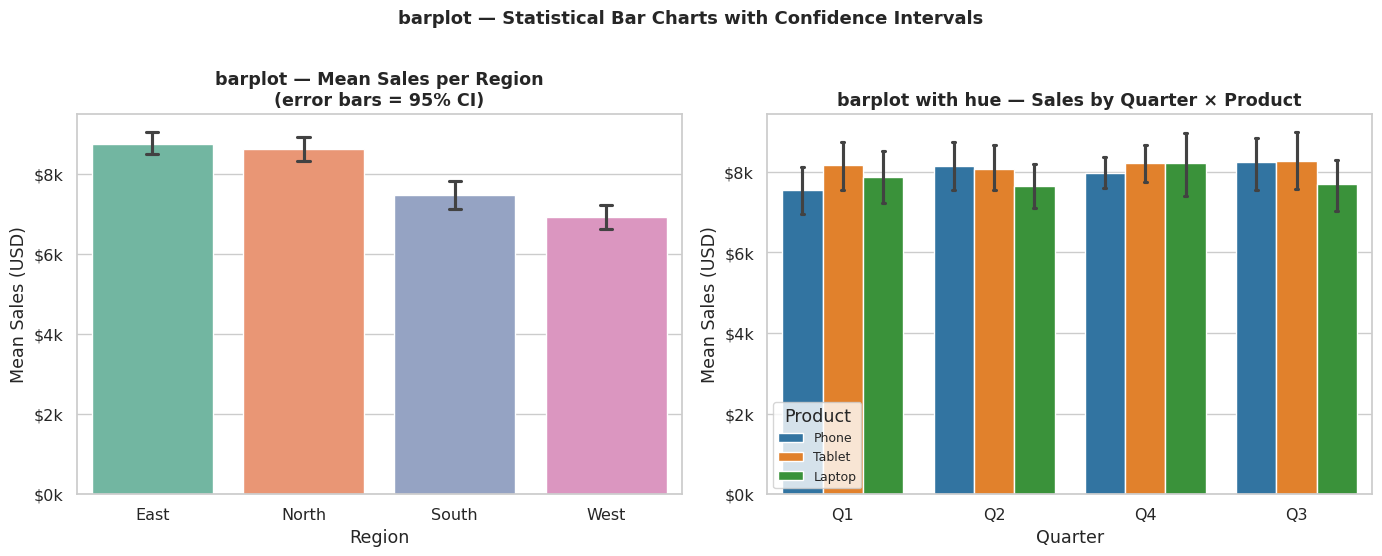

In [8]:
# ── Dataset: Product sales across regions and quarters ─────
np.random.seed(9)
n = 400

regions   = np.random.choice(['North', 'South', 'East', 'West'], n)
quarters  = np.random.choice(['Q1', 'Q2', 'Q3', 'Q4'], n)
products  = np.random.choice(['Laptop', 'Phone', 'Tablet'], n)

base_sales = {'North':8500, 'South':7200, 'East':9100, 'West':6800}
sales = np.array([base_sales[r] + np.random.normal(0, 1500) for r in regions])
sales = np.clip(sales, 2000, 18000)

df_sales = pd.DataFrame({
    'region'  : regions,
    'quarter' : quarters,
    'product' : products,
    'sales'   : sales,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── barplot: mean sales per region with CI bar ────────────
# Seaborn barplot automatically:
#   1. Groups data by x= column
#   2. Computes the MEAN of y= for each group
#   3. Draws an error bar = 95% confidence interval
# This is statistical — not just a simple sum bar chart
sns.barplot(data=df_sales,
            x='region',
            y='sales',
            hue='region',             # color each bar differently
            palette='Set2',
            edgecolor='white',
            capsize=0.08,             # width of the CI bar end-caps
            errorbar=('ci', 95),      # 95% confidence interval
            legend=False,
            ax=axes[0])

axes[0].set_title('barplot — Mean Sales per Region\n(error bars = 95% CI)',
                  fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Mean Sales (USD)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ── barplot with hue= — compare two categoricals ──────────
# hue= adds a SECOND categorical dimension as color groups
# This is the most common use: x=category1, hue=category2
sns.barplot(data=df_sales,
            x='quarter',
            y='sales',
            hue='product',             # 3 product bars per quarter
            palette='tab10',
            edgecolor='white',
            capsize=0.06,
            errorbar=('ci', 95),
            ax=axes[1])

axes[1].set_title('barplot with hue — Sales by Quarter × Product',
                  fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Mean Sales (USD)')
axes[1].legend(title='Product', fontsize=9)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

fig.suptitle('barplot — Statistical Bar Charts with Confidence Intervals',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
# PART 2 — Intermediate
---

<a id='box'></a>
## 5. Box Plot & Violin Plot — Statistical Summaries

Seaborn's `boxplot` and `violinplot` do the same job as Matplotlib's versions but with far cleaner syntax — pass a DataFrame and column names, and Seaborn handles grouping, coloring, and legends automatically.

**When to choose which:**
- **boxplot** → when you want the exact quartile values and outlier dots
- **violinplot** → when the shape of the distribution matters (reveals bimodal, skewed, etc.)
- **boxenplot** → best for large datasets (1000+ rows) — more quantile detail than boxplot


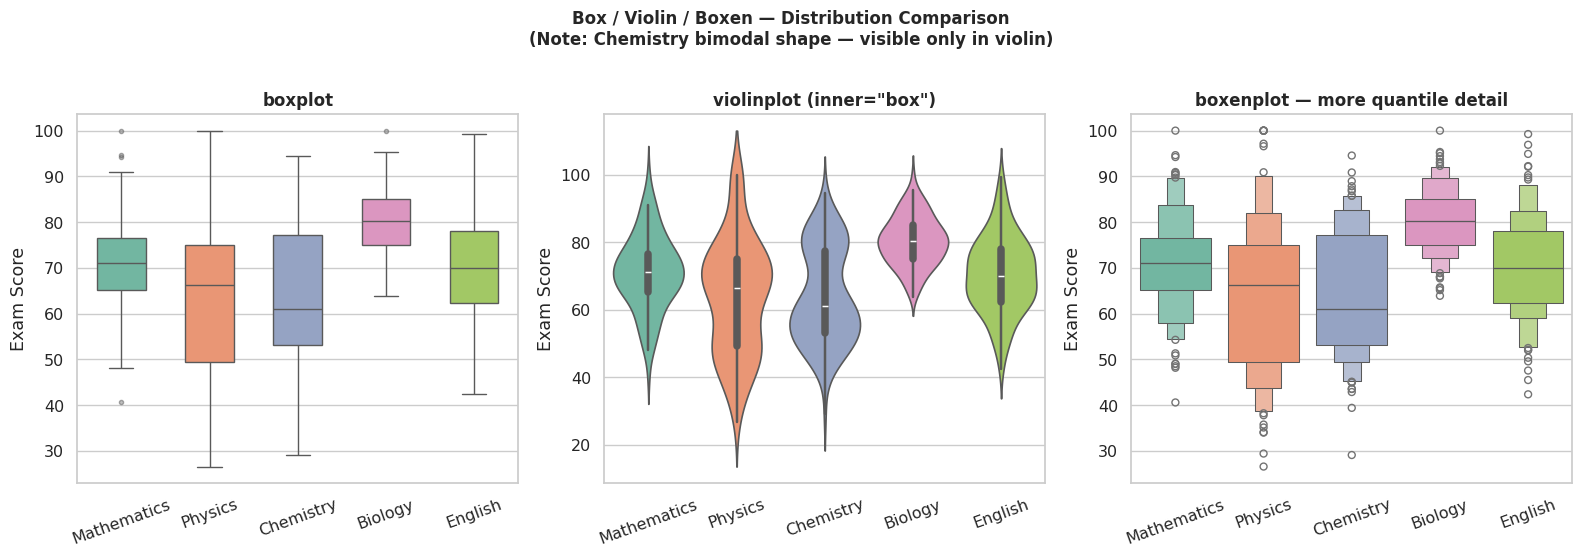

In [9]:
# ── Dataset: Student exam scores across subjects ─────────────
np.random.seed(42)

subjects = ['Mathematics', 'Physics', 'Chemistry', 'Biology', 'English']
records  = []
for subj in subjects:
    if subj == 'Physics':       # wide spread — hard subject
        scores = np.random.normal(63, 18, 120)
    elif subj == 'Chemistry':   # bimodal — some students get private tuition
        scores = np.concatenate([np.random.normal(55, 8, 80),
                                  np.random.normal(82, 6, 40)])
    elif subj == 'Biology':     # high mean, narrow spread
        scores = np.random.normal(80, 7, 120)
    else:
        scores = np.random.normal(72, 12, 120)

    scores = np.clip(scores, 0, 100)
    for s in scores:
        records.append({'subject': subj, 'score': s})

df_scores = pd.DataFrame(records)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# ── 1. boxplot ────────────────────────────────────────────
# x= → category (grouped by subject)
# y= → numerical value to summarise
# hue= (optional) → further split by another categorical variable
sns.boxplot(data=df_scores,
            x='subject',
            y='score',
            hue='subject',
            palette='Set2',
            width=0.55,         # width of the box
            flierprops=dict(marker='o', markerfacecolor='gray',
                            markersize=3, alpha=0.5),   # outlier style
            legend=False,
            ax=axes[0])
axes[0].set_title('boxplot', fontweight='bold', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylabel('Exam Score')

# ── 2. violinplot ─────────────────────────────────────────
# inner='box'   → shows a tiny boxplot inside the violin
# inner='quart' → shows quartile lines instead
# split=True    → if hue has 2 levels, draw halves on each side
sns.violinplot(data=df_scores,
               x='subject',
               y='score',
               hue='subject',
               palette='Set2',
               inner='box',      # tiny boxplot inside violin
               linewidth=1.2,
               legend=False,
               ax=axes[1])
axes[1].set_title('violinplot (inner="box")', fontweight='bold', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('Exam Score')

# ── 3. boxenplot (letter-value plot) ──────────────────────
# boxenplot is ideal for larger datasets.
# It shows more quantile boxes than a standard boxplot,
# making the tail behaviour visible without showing every outlier.
sns.boxenplot(data=df_scores,
              x='subject',
              y='score',
              hue='subject',
              palette='Set2',
              legend=False,
              ax=axes[2])
axes[2].set_title('boxenplot — more quantile detail', fontweight='bold', fontsize=12)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)
axes[2].set_ylabel('Exam Score')

# Key observation: Chemistry's violin (middle) clearly shows TWO humps
# (bimodal distribution) — completely invisible in the boxplot!

fig.suptitle('Box / Violin / Boxen — Distribution Comparison\n'
             '(Note: Chemistry bimodal shape — visible only in violin)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


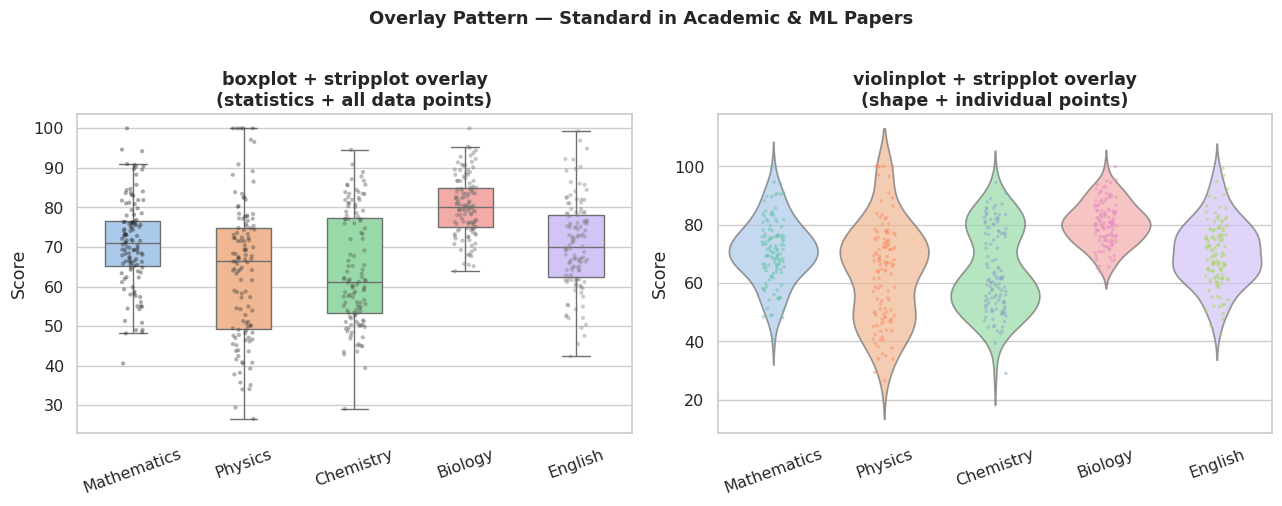

In [10]:
# ── stripplot + boxplot overlay — show ALL data points ────────
# This pattern is standard in academic publications and ML papers.
# The box gives you statistics; the strip shows every individual data point.
# Together they give the full picture.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: box + strip overlay ─────────────────────────────
# Draw boxplot first (no outliers — the strip will show them)
sns.boxplot(data=df_scores, x='subject', y='score',
            hue='subject', palette='pastel',
            width=0.5, fliersize=0,   # fliersize=0 hides boxplot outliers
            legend=False, ax=axes[0])

# Overlay individual points — jitter=True spreads overlapping points horizontally
# Use a darker palette so points are visible against the pastel boxes
sns.stripplot(data=df_scores, x='subject', y='score',
              hue='subject', palette='dark:gray',
              size=3, alpha=0.4,
              jitter=True,    # adds small horizontal noise to separate overlapping points
              legend=False,
              ax=axes[0])

axes[0].set_title('boxplot + stripplot overlay\n(statistics + all data points)',
                  fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_xlabel('')
axes[0].set_ylabel('Score')

# ── Right: violinplot + stripplot overlay ─────────────────
sns.violinplot(data=df_scores, x='subject', y='score',
               hue='subject', palette='pastel',
               inner=None,         # inner=None removes inner box — strip shows detail
               alpha=0.7,
               legend=False,
               ax=axes[1])

sns.stripplot(data=df_scores, x='subject', y='score',
              hue='subject', palette='Set2',
              size=2.5, alpha=0.5,
              jitter=True,
              legend=False,
              ax=axes[1])

axes[1].set_title('violinplot + stripplot overlay\n(shape + individual points)',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_xlabel('')
axes[1].set_ylabel('Score')

fig.suptitle('Overlay Pattern — Standard in Academic & ML Papers',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<a id='heatmap'></a>
## 6. Heatmap — Correlations & Confusion Matrices

`sns.heatmap()` is the **single most-used Seaborn function in ML workflows**. You will use it every project for two things:

1. **Correlation matrix** during EDA — which features are linearly related?
2. **Confusion matrix** after model evaluation — where is the classifier making mistakes?

Mastering `sns.heatmap()` is non-negotiable.


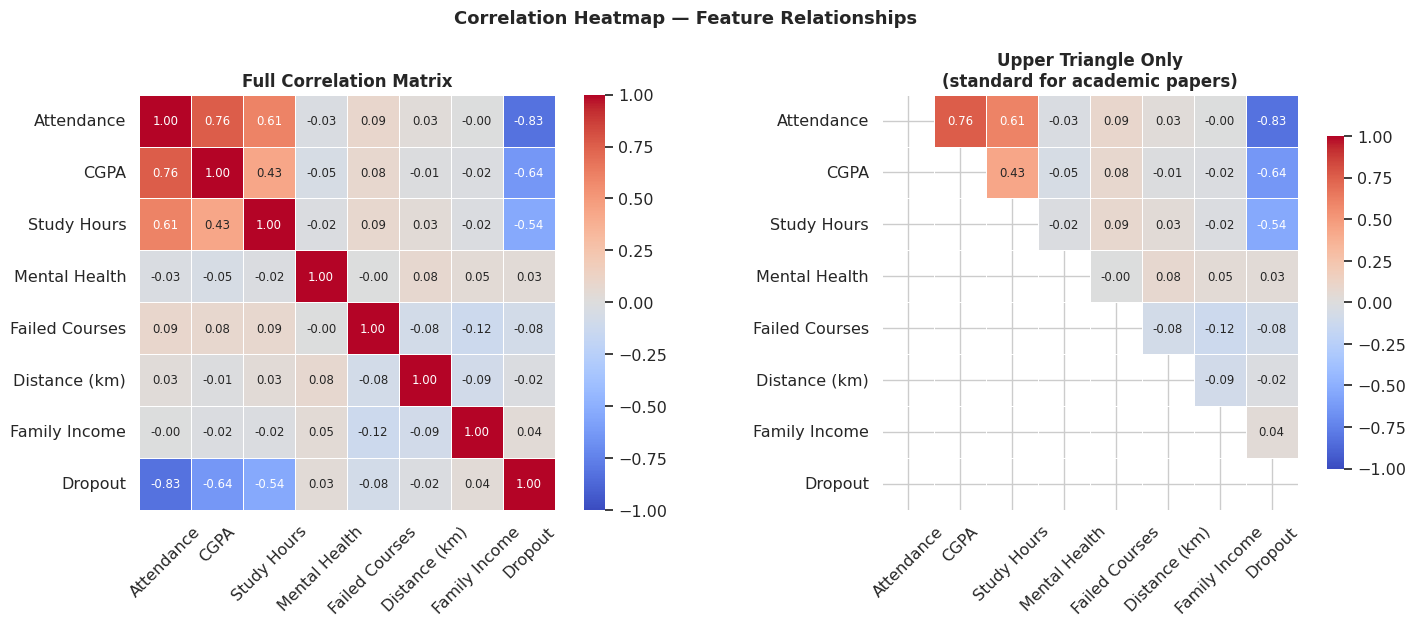

In [11]:
# ── 1. Correlation Matrix Heatmap ─────────────────────────────
np.random.seed(10)

# Simulate a student dataset with realistic feature correlations
n = 400
attendance  = np.random.uniform(40, 100, n)
cgpa        = 1.5 + 0.025 * attendance + np.random.normal(0, 0.4, n)
study_hrs   = 1 + 0.04 * attendance + np.random.normal(0, 1, n)
mental_h    = np.random.uniform(2, 10, n)
failed_c    = np.random.poisson(1.5, n) - 0.3 * (cgpa - 2)
distance    = np.random.exponential(15, n)
family_inc  = np.random.choice([0, 1, 2], n)
dropout     = ((attendance < 60) | (cgpa < 2.0)).astype(int)

df_corr = pd.DataFrame({
    'Attendance'    : np.clip(attendance, 0, 100),
    'CGPA'          : np.clip(cgpa, 0, 4),
    'Study Hours'   : np.clip(study_hrs, 0, 12),
    'Mental Health' : np.clip(mental_h, 1, 10),
    'Failed Courses': np.clip(failed_c.astype(int), 0, 8),
    'Distance (km)' : np.clip(distance, 0, 100),
    'Family Income' : family_inc,
    'Dropout'       : dropout,
})

corr_matrix = df_corr.corr()   # pandas computes Pearson correlation for all pairs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Full correlation matrix ────────────────────────────────
# annot=True    → print the correlation value in each cell
# fmt='.2f'     → 2 decimal places
# cmap='coolwarm'  → blue=negative, red=positive (diverging palette)
# vmin/vmax     → fix scale to [-1, 1] (full correlation range)
# linewidths    → thin white grid lines between cells
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            center=0,            # center the colormap at 0 (no correlation)
            linewidths=0.5,
            linecolor='white',
            square=True,         # make each cell square
            ax=axes[0],
            annot_kws={'size': 8.5})

axes[0].set_title('Full Correlation Matrix', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# ── Upper triangle only (cleaner for papers) ──────────────
# The matrix is symmetric — lower triangle is redundant.
# mask= hides cells where mask=True.
# np.tril returns lower triangle (True = lower), so we mask those.
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))  # True = lower triangle
mask_upper = ~mask     # invert to hide lower triangle instead

sns.heatmap(corr_matrix,
            mask=mask,           # hide lower triangle — show upper only
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            center=0,
            linewidths=0.5,
            linecolor='white',
            square=True,
            ax=axes[1],
            annot_kws={'size': 8.5},
            cbar_kws={'shrink': 0.8})

axes[1].set_title('Upper Triangle Only\n(standard for academic papers)',
                  fontweight='bold', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

fig.suptitle('Correlation Heatmap — Feature Relationships',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


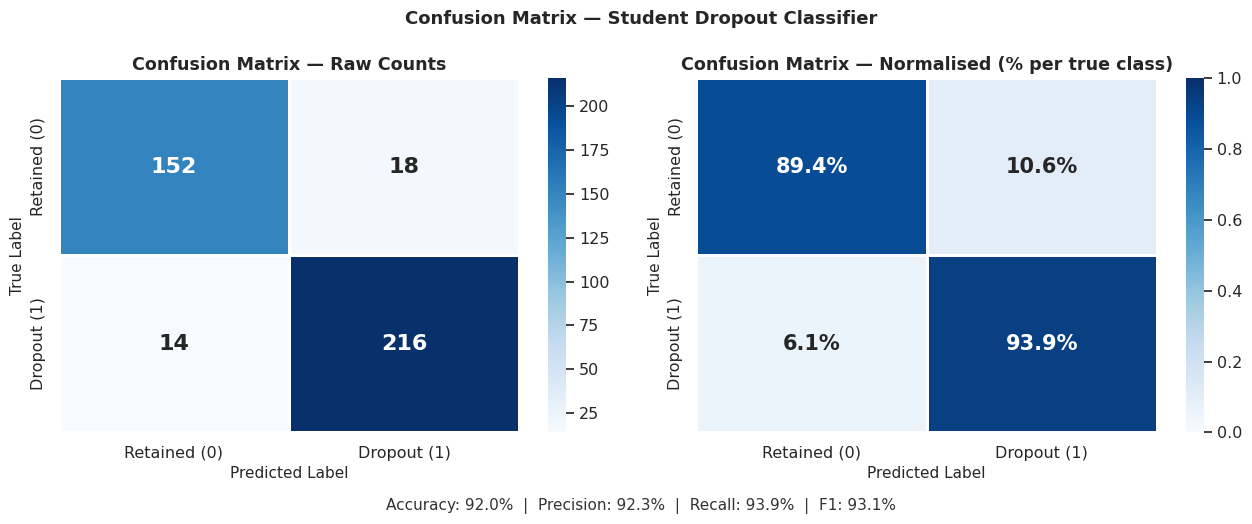

In [12]:
# ── 2. Confusion Matrix Heatmap ──────────────────────────────
# Standard pattern for every classification project.
# This is exactly what you'd put in a project report or thesis.

from sklearn.metrics import confusion_matrix

# Simulate model predictions (realistic — not perfect)
np.random.seed(42)
y_true = np.array([0]*170 + [1]*230)   # 400 test students
# Model makes some mistakes:
y_pred = y_true.copy()
# Flip some predictions to simulate errors
wrong_0 = np.random.choice(np.where(y_true==0)[0], 18, replace=False)
wrong_1 = np.random.choice(np.where(y_true==1)[0], 14, replace=False)
y_pred[wrong_0] = 1   # false positives
y_pred[wrong_1] = 0   # false negatives

cm     = confusion_matrix(y_true, y_pred)
labels = ['Retained (0)', 'Dropout (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Standard confusion matrix ─────────────────────────────
sns.heatmap(cm,
            annot=True,
            fmt='d',             # 'd' = integer format (no decimals)
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            linewidths=1,
            linecolor='white',
            ax=axes[0],
            annot_kws={'size': 16, 'weight': 'bold'})

axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# ── Normalised confusion matrix (%) ───────────────────────
# Normalising by row ('true') gives recall per class.
# This is more informative when class sizes differ.
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm,
            annot=True,
            fmt='.1%',           # '.1%' formats 0.94 as '94.0%'
            cmap='Blues',
            vmin=0, vmax=1,
            xticklabels=labels,
            yticklabels=labels,
            linewidths=1,
            linecolor='white',
            ax=axes[1],
            annot_kws={'size': 15, 'weight': 'bold'})

axes[1].set_title('Confusion Matrix — Normalised (% per true class)',
                  fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

# Key metrics annotation
TP=cm[1,1]; FP=cm[0,1]; FN=cm[1,0]; TN=cm[0,0]; total=cm.sum()
precision = TP/(TP+FP); recall = TP/(TP+FN); acc = (TP+TN)/total
fig.text(0.5, -0.02,
         f'Accuracy: {acc:.1%}  |  Precision: {precision:.1%}  |  Recall: {recall:.1%}  |  F1: {2*precision*recall/(precision+recall):.1%}',
         ha='center', fontsize=11, color='#333')

fig.suptitle('Confusion Matrix — Student Dropout Classifier',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='pairplot'></a>
## 7. Pairplot — Full EDA in One Line

`sns.pairplot()` is arguably the most powerful single function in Seaborn. It generates a grid where:
- **Diagonal** → distribution of each variable
- **Off-diagonal** → scatter plot of every variable pair

What would take 30+ lines in Matplotlib takes **one line** in Seaborn. It is the standard first step in any ML EDA workflow.

> **Real usage:** Run `sns.pairplot(df, hue='target')` immediately after loading any dataset. It reveals correlations, clusters, outliers, and class separability in seconds.


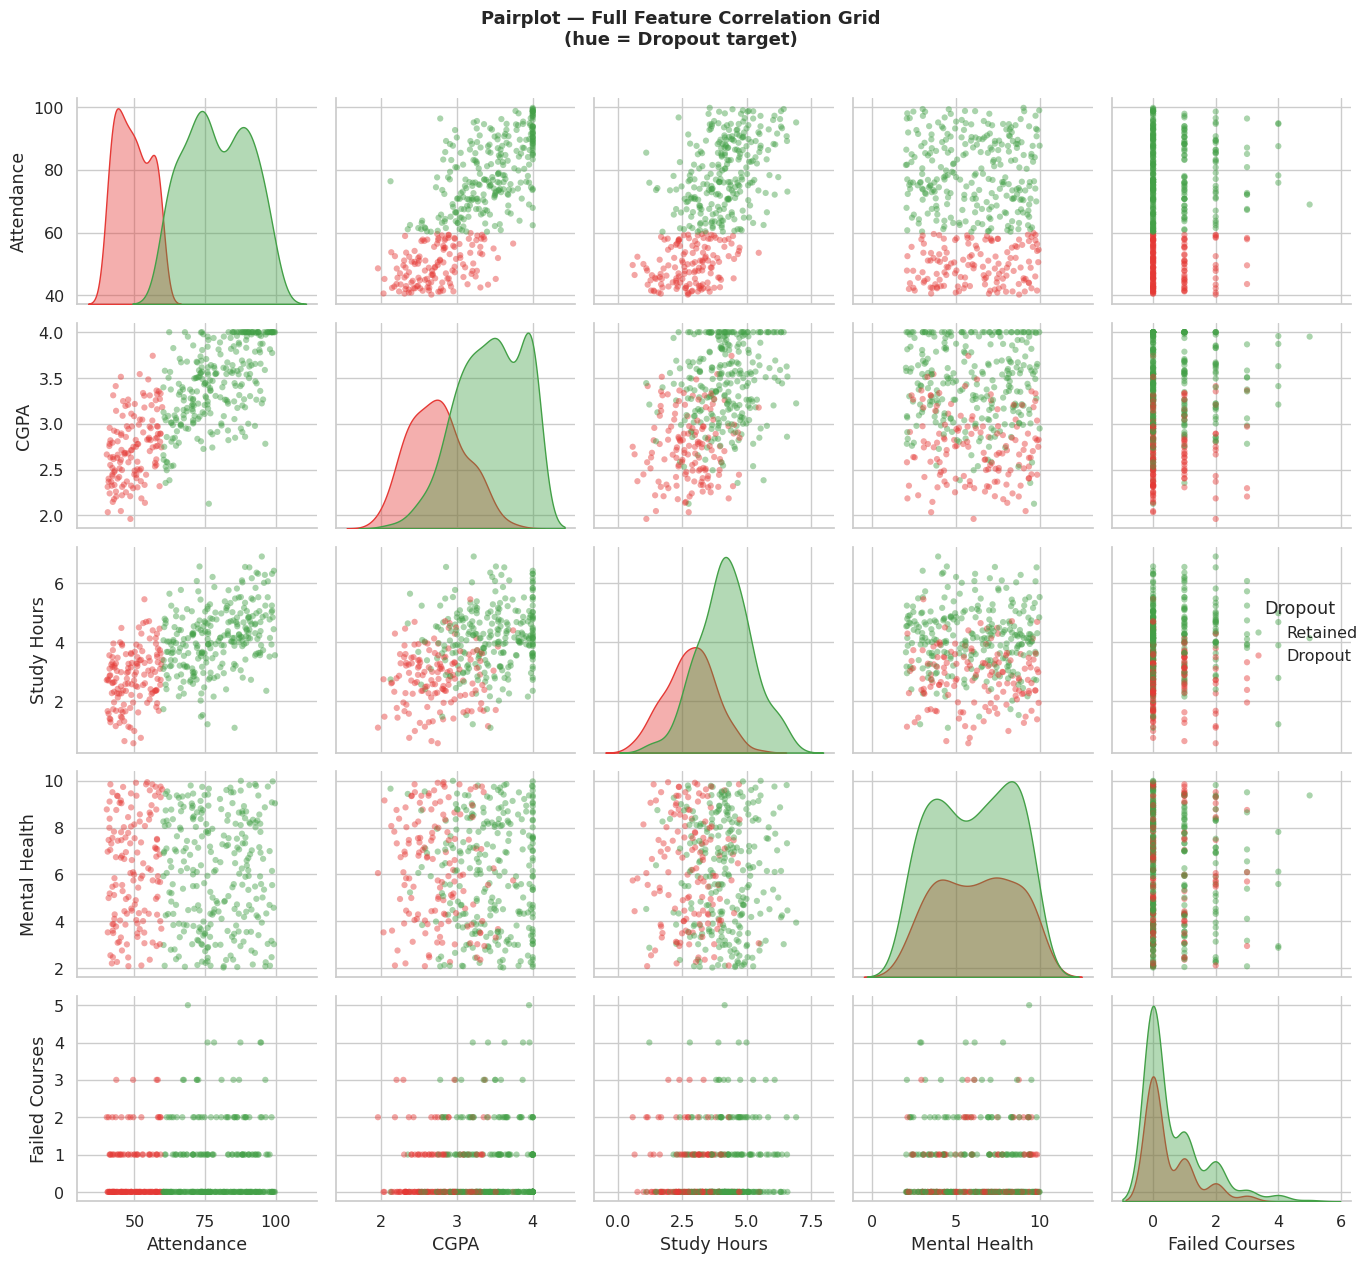


Key observations from the pairplot:
  → Attendance vs CGPA: clear separation between classes (best features)
  → Failed Courses: Dropout cluster skews high
  → Mental Health: weaker separation (less predictive alone)
  → Study Hours + Attendance: correlated (expected)


In [13]:
# ── pairplot on the student dropout dataset ───────────────────
# Select the most important features — don't include all columns
# (too many columns makes the grid unreadably small)

df_pair = df_corr[['Attendance', 'CGPA', 'Study Hours',
                    'Mental Health', 'Failed Courses', 'Dropout']].copy()
df_pair['Dropout'] = df_pair['Dropout'].map({0: 'Retained', 1: 'Dropout'})

# ── Basic pairplot with hue ────────────────────────────────
# hue='Dropout' colors every plot by the target class —
# this immediately shows which features separate the two groups
# diag_kind='kde' → diagonal shows smooth density instead of histogram
# plot_kws  → kwargs passed to the scatter plots
# diag_kws  → kwargs passed to the diagonal plots
g = sns.pairplot(df_pair,
                 hue='Dropout',
                 palette={'Dropout':'#E53935', 'Retained':'#43A047'},
                 diag_kind='kde',      # diagonal: KDE curves per class
                 plot_kws=dict(alpha=0.45, s=20, edgecolor='none'),
                 diag_kws=dict(fill=True, alpha=0.4))

g.figure.suptitle('Pairplot — Full Feature Correlation Grid\n(hue = Dropout target)',
                  fontsize=13, fontweight='bold', y=1.01)

# pairplot returns a PairGrid object (g), not a regular Axes
# Use g.figure to access the Figure for suptitle, saving, etc.
plt.tight_layout()
plt.show()

print("\nKey observations from the pairplot:")
print("  → Attendance vs CGPA: clear separation between classes (best features)")
print("  → Failed Courses: Dropout cluster skews high")
print("  → Mental Health: weaker separation (less predictive alone)")
print("  → Study Hours + Attendance: correlated (expected)")


<a id='regression'></a>
## 8. Regression Plots — regplot & lmplot

Seaborn's regression plots draw a scatter plot **with a fitted regression line and confidence interval** automatically. No need to compute the regression manually.

| Function | When to use |
|----------|------------|
| `regplot` | Single scatter + regression line (axes-level) |
| `lmplot` | Same but supports `hue`, `col`, `row` for subplots (figure-level) |

> **Key insight:** `lmplot` is a figure-level function — it creates its own Figure and cannot be placed into an existing `ax`. Use `regplot` when you need to embed into a subplot grid.


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

...

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

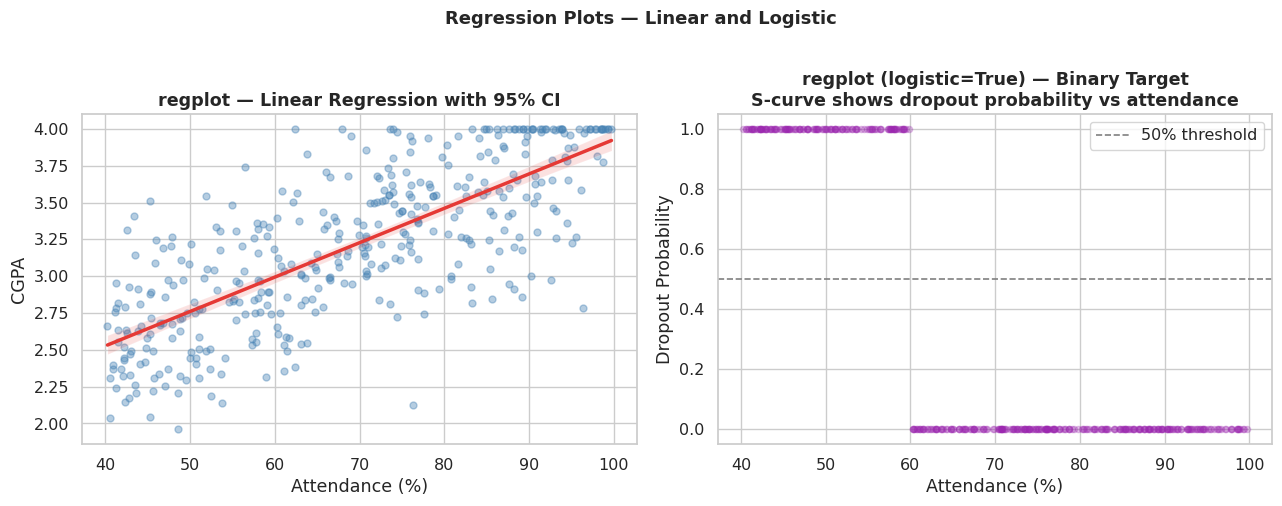

In [14]:
# ── regplot vs lmplot — when to use each ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 1. regplot — axes-level, fits into any subplot ────────
# ci=95     → shade the 95% confidence interval around the regression line
# scatter_kws → passed to the underlying scatter (size, alpha, color)
# line_kws    → passed to the regression line
sns.regplot(data=df_corr,
            x='Attendance',
            y='CGPA',
            ci=95,
            scatter_kws=dict(alpha=0.4, s=25, color='steelblue'),
            line_kws=dict(color='#E53935', linewidth=2.5),
            ax=axes[0])

axes[0].set_title('regplot — Linear Regression with 95% CI',
                  fontweight='bold')
axes[0].set_xlabel('Attendance (%)')
axes[0].set_ylabel('CGPA')

# ── 2. regplot with logistic=True — for binary target ─────
# logistic=True fits a logistic regression curve (S-shape)
# Essential when y= is a binary 0/1 variable (like dropout)
# This is a VERY common pattern in ML binary classification analysis
sns.regplot(data=df_corr,
            x='Attendance',
            y='Dropout',
            logistic=True,      # logistic regression curve instead of linear
            ci=95,
            scatter_kws=dict(alpha=0.25, s=20, color='#9C27B0'),
            line_kws=dict(color='#E53935', linewidth=2.5),
            ax=axes[1])

axes[1].set_title('regplot (logistic=True) — Binary Target\n'
                  'S-curve shows dropout probability vs attendance',
                  fontweight='bold')
axes[1].set_xlabel('Attendance (%)')
axes[1].set_ylabel('Dropout Probability')
axes[1].axhline(0.5, color='gray', linestyle='--', lw=1.2,
                label='50% threshold')
axes[1].legend()

fig.suptitle('Regression Plots — Linear and Logistic',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


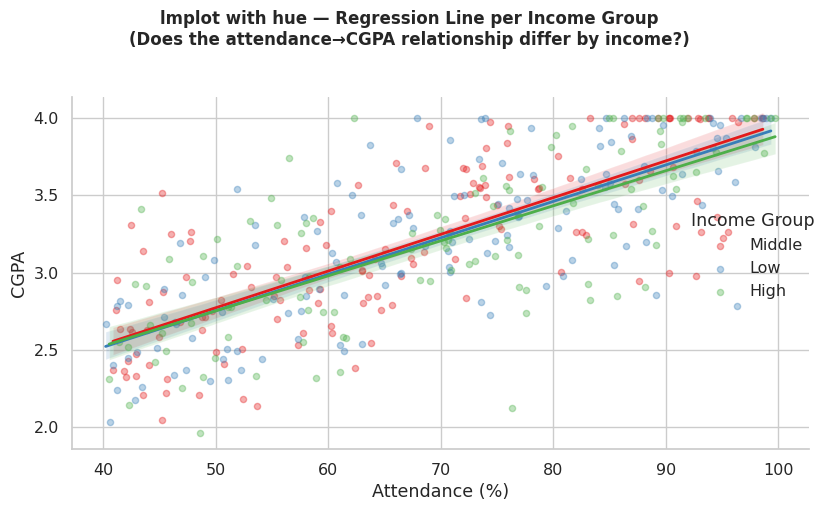

In [15]:
# ── lmplot — regression across multiple groups (hue) ──────────
# lmplot is figure-level: it creates its OWN figure.
# You CANNOT pass ax= to lmplot. Control size with height= and aspect=.

# Split the data into income groups for comparison
df_lm = df_corr.copy()
df_lm['Income Group'] = df_lm['Family Income'].map(
    {0: 'Low', 1: 'Middle', 2: 'High'})
df_lm['Dropout Label'] = df_lm['Dropout'].map({0:'Retained', 1:'Dropout'})

# lmplot with hue= draws a SEPARATE regression line per group —
# letting you compare whether the relationship differs across categories
g = sns.lmplot(data=df_lm,
               x='Attendance',
               y='CGPA',
               hue='Income Group',
               palette='Set1',
               height=5,          # height of each subplot panel in inches
               aspect=1.4,        # width = height × aspect
               scatter_kws=dict(alpha=0.35, s=20),
               line_kws=dict(linewidth=2),
               ci=90)

g.set_axis_labels('Attendance (%)', 'CGPA')
g.figure.suptitle('lmplot with hue — Regression Line per Income Group\n'
                  '(Does the attendance→CGPA relationship differ by income?)',
                  fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


---
# PART 3 — Advanced & Practical
---

<a id='facet'></a>
## 9. FacetGrid — Conditional Subplots

`FacetGrid` lets you repeat the same plot for different subsets of your data across a grid of panels. Instead of writing a loop and manually managing subplots, you define the grid and map a plotting function onto it.

**Use it when:** You want to see how a relationship or distribution changes across the levels of a categorical variable.


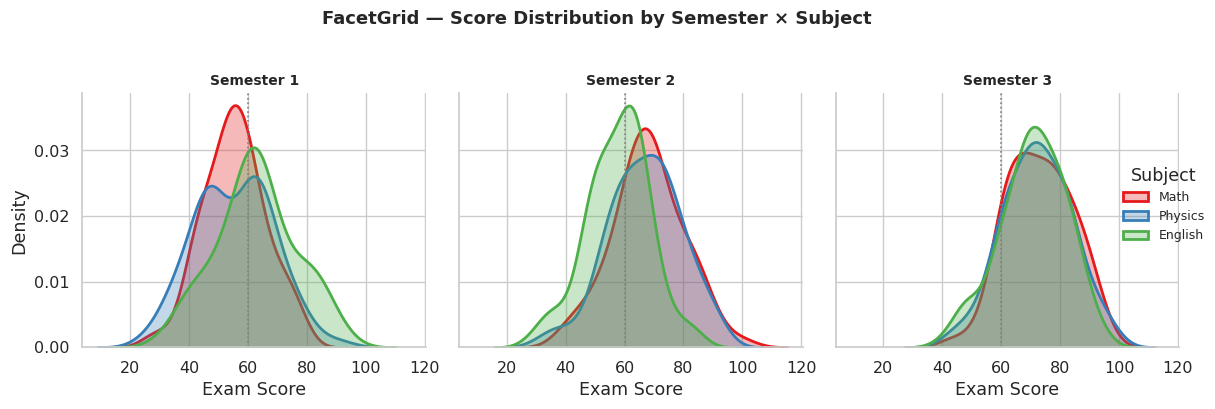

In [16]:
# ── FacetGrid: distribution of scores per subject per semester ─
np.random.seed(33)

semesters = ['Semester 1', 'Semester 2', 'Semester 3']
subjs     = ['Math', 'Physics', 'English']
records   = []
for sem_i, sem in enumerate(semesters):
    for subj in subjs:
        base  = 60 + sem_i*5   # scores improve each semester
        scores = np.random.normal(base + np.random.uniform(-5,5), 12, 80)
        for s in scores:
            records.append({'semester':sem, 'subject':subj,
                            'score':np.clip(s,0,100)})

df_facet = pd.DataFrame(records)

# ── FacetGrid workflow ─────────────────────────────────────
# Step 1: Create the grid — define rows and/or columns
# col=  → one column per category level
# row=  → one row per category level (optional)
# col_wrap= → after N columns, wrap to next row (when no row= defined)
g = sns.FacetGrid(df_facet,
                  col='semester',       # 3 panels — one per semester
                  hue='subject',        # color lines by subject within each panel
                  height=4,
                  aspect=0.95,
                  palette='Set1',
                  sharey=True)          # same y-axis across all panels

# Step 2: Map a plot function onto the grid
# g.map(function, x_column, **kwargs)
# The function is called once per panel with the subset of data for that panel
g.map(sns.kdeplot, 'score', fill=True, alpha=0.3, linewidth=2)

# Step 3: Add shared legend and formatting
g.add_legend(title='Subject', fontsize=9)
g.set_axis_labels('Exam Score', 'Density')
g.set_titles(col_template='{col_name}')   # panel title = semester name

for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontweight='bold', fontsize=10)
    ax.axvline(60, color='gray', linestyle=':', linewidth=1.2, label='Pass mark')

g.figure.suptitle('FacetGrid — Score Distribution by Semester × Subject',
                  fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


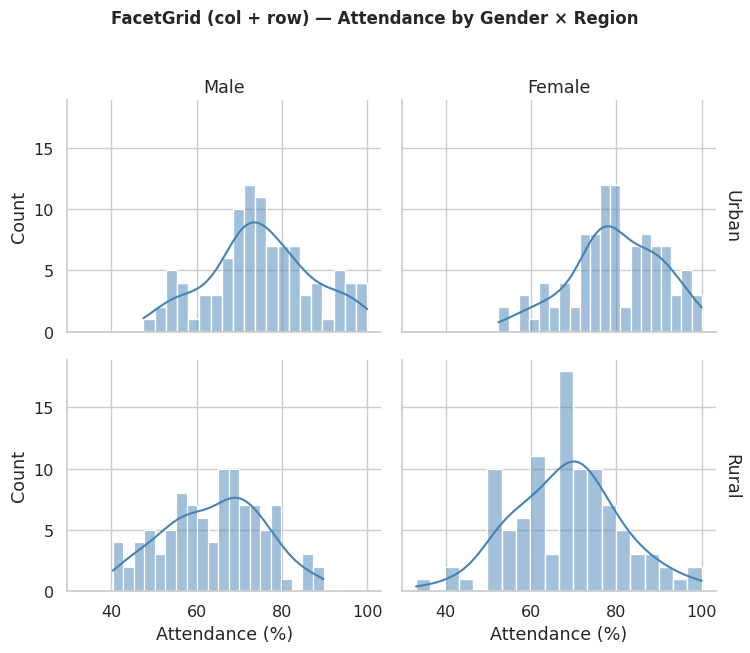

In [17]:
# ── FacetGrid with col + row — 2D conditional grid ───────────
# Both col= and row= gives a full 2D facet grid.
# This is powerful for exploring interactions between two categoricals.

np.random.seed(7)
genders  = ['Male', 'Female']
regions  = ['Urban', 'Rural']
records2 = []
for g_val in genders:
    for r_val in regions:
        base_att = (75 if g_val=='Female' else 70) + (5 if r_val=='Urban' else -5)
        att = np.random.normal(base_att, 12, 100)
        for a in att:
            records2.append({'gender':g_val, 'region':r_val,
                             'attendance':np.clip(a,0,100)})

df_grid = pd.DataFrame(records2)

g2 = sns.FacetGrid(df_grid,
                   col='gender',
                   row='region',
                   height=3.2,
                   aspect=1.2,
                   margin_titles=True)  # titles on right margin (cleaner)

g2.map(sns.histplot, 'attendance',
       bins=20, color='steelblue',
       edgecolor='white', kde=True)

g2.set_axis_labels('Attendance (%)', 'Count')
g2.set_titles(col_template='{col_name}', row_template='{row_name}')

g2.figure.suptitle('FacetGrid (col + row) — Attendance by Gender × Region',
                   fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<a id='eda'></a>
## 10. Real-World EDA Workflow

This section shows the **exact sequence of Seaborn plots** you would run when you receive a new dataset. This is the workflow used in real ML projects, Kaggle competitions, and research papers.

```
Load data → Check shape & dtypes → Target distribution →
Feature distributions → Correlation heatmap → Pairplot →
Feature vs Target relationships → Save findings
```


In [18]:
# ── Full EDA on the Student Dropout Dataset ───────────────────
# Reuse df_corr built earlier — same structure as a real ML dataset

print("=" * 55)
print("  STEP 1 — Dataset Overview")
print("=" * 55)
print(f"\n  Shape      : {df_corr.shape[0]} rows × {df_corr.shape[1]} columns")
print(f"  Null values: {df_corr.isnull().sum().sum()}")
print(f"\n  Dtypes:\n{df_corr.dtypes.to_string()}")
print(f"\n  Descriptive stats:")
print(df_corr.describe().round(2).to_string())


  STEP 1 — Dataset Overview

  Shape      : 400 rows × 8 columns
  Null values: 0

  Dtypes:
Attendance        float64
CGPA              float64
Study Hours       float64
Mental Health     float64
Failed Courses      int64
Distance (km)     float64
Family Income       int64
Dropout             int64

  Descriptive stats:
       Attendance    CGPA  Study Hours  Mental Health  Failed Courses  Distance (km)  Family Income  Dropout
count      400.00  400.00       400.00         400.00          400.00         400.00         400.00   400.00
mean        68.96    3.20         3.69           6.11            0.60          14.71           0.94     0.35
std         17.17    0.53         1.21           2.34            0.93          14.82           0.80     0.48
min         40.24    1.96         0.57           2.03            0.00           0.04           0.00     0.00
25%         53.70    2.81         2.86           4.03            0.00           3.40           0.00     0.00
50%         70.36    3.

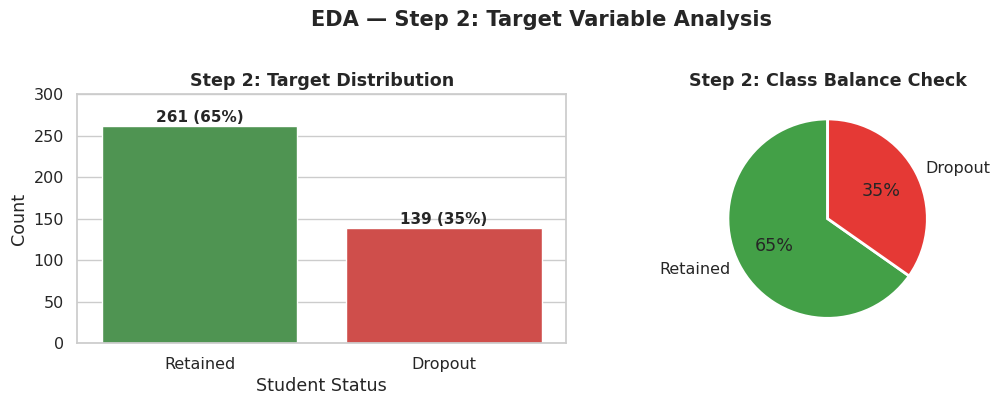


  Class imbalance ratio: 0.53:1
  → Mild imbalance. Consider class_weight='balanced' in model.


In [19]:
# ── STEP 2 — Target variable distribution ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

dropout_counts = df_corr['Dropout'].value_counts()
colors_target  = ['#43A047', '#E53935']

# countplot
labels_map = {0: 'Retained', 1: 'Dropout'}
df_plot = df_corr.copy()
df_plot['Status'] = df_plot['Dropout'].map(labels_map)

sns.countplot(data=df_plot, x='Status',
              hue='Status',
              palette={'Retained':'#43A047', 'Dropout':'#E53935'},
              edgecolor='white', legend=False, ax=ax1)

for patch in ax1.patches:
    count = int(patch.get_height())
    pct   = count / len(df_plot) * 100
    ax1.text(patch.get_x() + patch.get_width()/2,
             patch.get_height() + 5,
             f'{count} ({pct:.0f}%)',
             ha='center', fontsize=11, fontweight='bold')

ax1.set_title('Step 2: Target Distribution', fontweight='bold')
ax1.set_xlabel('Student Status')
ax1.set_ylabel('Count')
ax1.set_ylim(0, 300)

# Pie for proportion
ax2.pie(dropout_counts.values,
        labels=['Retained', 'Dropout'],
        colors=colors_target,
        autopct='%1.0f%%',
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Step 2: Class Balance Check', fontweight='bold')

plt.suptitle('EDA — Step 2: Target Variable Analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n  Class imbalance ratio: {dropout_counts[1]/dropout_counts[0]:.2f}:1")
print("  → Mild imbalance. Consider class_weight='balanced' in model.")


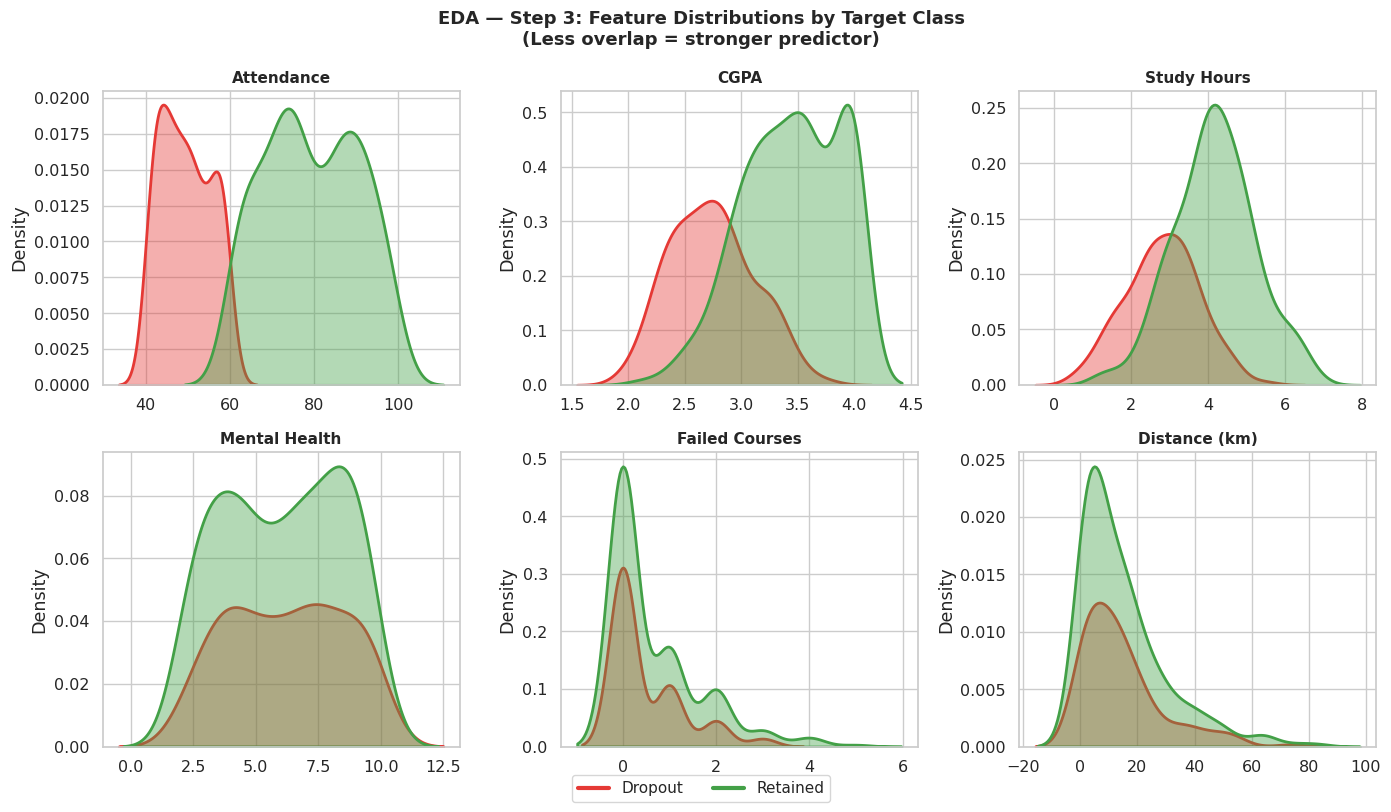


Key findings:
  → Attendance : HIGH separation → strongest predictor
  → CGPA       : HIGH separation → strong predictor
  → Failed Courses: MODERATE separation
  → Distance    : LOW separation → weak predictor


In [20]:
# ── STEP 3 — All feature distributions split by target ─────────
# Standard pattern: one KDE plot per feature, colored by target class.
# The degree of overlap tells you how predictive each feature is.

df_eda = df_corr.copy()
df_eda['Status'] = df_eda['Dropout'].map({0:'Retained', 1:'Dropout'})

features = ['Attendance', 'CGPA', 'Study Hours',
            'Mental Health', 'Failed Courses', 'Distance (km)']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, feat in zip(axes.flat, features):
    sns.kdeplot(data=df_eda, x=feat, hue='Status',
                fill=True, alpha=0.40, linewidth=2,
                palette={'Dropout':'#E53935', 'Retained':'#43A047'},
                ax=ax)
    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.legend_.remove() if ax.legend_ else None

# Shared legend
handles = [
    plt.Line2D([0],[0], color='#E53935', lw=3, label='Dropout'),
    plt.Line2D([0],[0], color='#43A047', lw=3, label='Retained'),
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('EDA — Step 3: Feature Distributions by Target Class\n'
             '(Less overlap = stronger predictor)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey findings:")
print("  → Attendance : HIGH separation → strongest predictor")
print("  → CGPA       : HIGH separation → strong predictor")
print("  → Failed Courses: MODERATE separation")
print("  → Distance    : LOW separation → weak predictor")


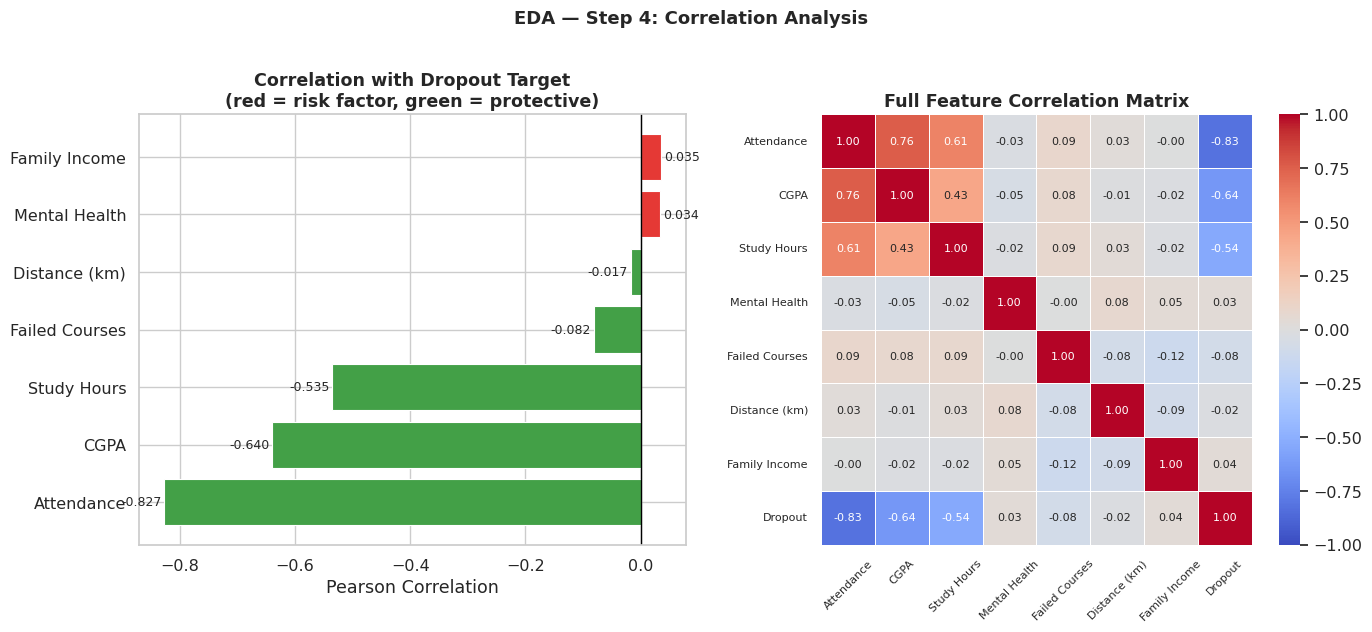

In [21]:
# ── STEP 4 — Correlation heatmap + feature importance bar ─────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Correlation with target column only ───────────────────
# Drop 'Dropout' from features, compute correlation vs target
target_corr = df_corr.corr()['Dropout'].drop('Dropout').sort_values()

# Color bars: positive correlation = red (risk factor), negative = green (protective)
bar_colors = ['#E53935' if v > 0 else '#43A047' for v in target_corr.values]

ax1.barh(target_corr.index, target_corr.values,
         color=bar_colors, edgecolor='white', linewidth=0.8)
ax1.axvline(0, color='black', linewidth=1)
ax1.set_title('Correlation with Dropout Target\n(red = risk factor, green = protective)',
              fontweight='bold')
ax1.set_xlabel('Pearson Correlation')

for i, (feat, val) in enumerate(target_corr.items()):
    ax1.text(val + (0.005 if val >= 0 else -0.005),
             i, f'{val:.3f}',
             va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=9)

# ── Full heatmap ───────────────────────────────────────────
sns.heatmap(df_corr.corr(),
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            square=True, ax=ax2,
            annot_kws={'size': 8})
ax2.set_title('Full Feature Correlation Matrix', fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.tick_params(axis='y', rotation=0, labelsize=8)

fig.suptitle('EDA — Step 4: Correlation Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<a id='combo'></a>
## 11. Seaborn + Matplotlib — Fine-Tuning Plots

Every Seaborn plot returns a Matplotlib `Axes` object. This means after drawing with Seaborn, you can use any Matplotlib command to customize further.

This is the most practical skill — knowing when to let Seaborn do the heavy lifting, and when to switch to Matplotlib for the finishing touches.


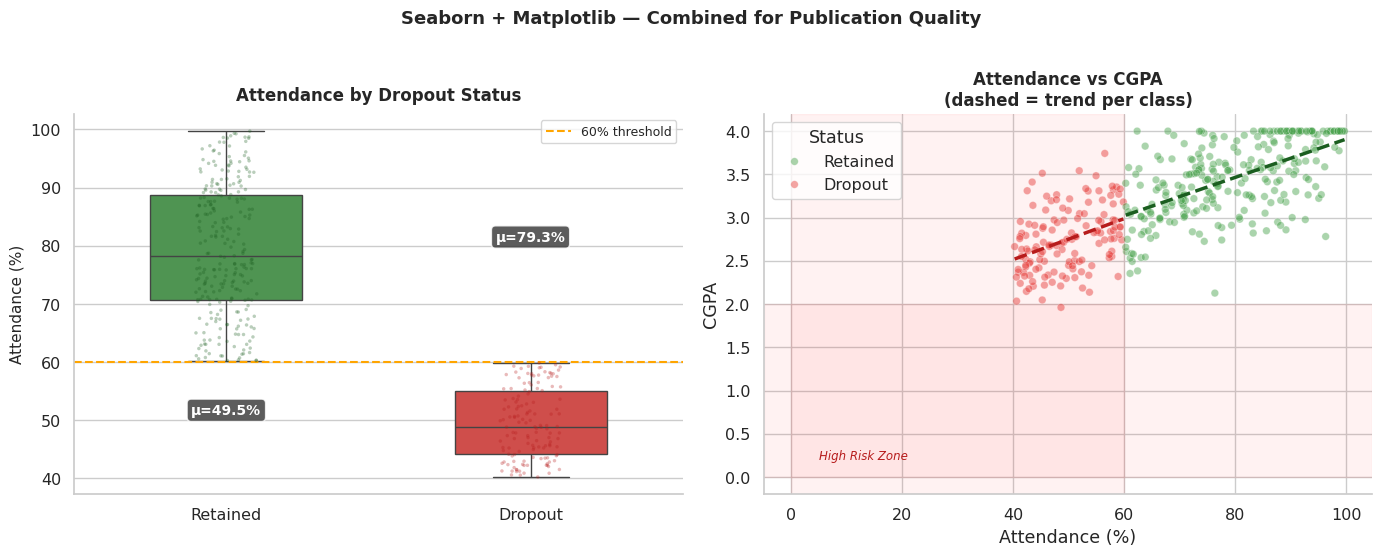

In [22]:
# ── Pattern: Seaborn for the chart, Matplotlib for the details ─

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ══════════════════════════════════════════════════════════
# LEFT: Publication-ready box plot
# ══════════════════════════════════════════════════════════

# Step 1: Seaborn draws the chart
sns.boxplot(data=df_eda, x='Status', y='Attendance',
            hue='Status',
            palette={'Dropout':'#E53935', 'Retained':'#43A047'},
            width=0.5, fliersize=3,
            legend=False,
            ax=axes[0])

sns.stripplot(data=df_eda, x='Status', y='Attendance',
              hue='Status',
              palette={'Dropout':'#B71C1C', 'Retained':'#1B5E20'},
              size=2.5, alpha=0.3, jitter=True,
              legend=False,
              ax=axes[0])

# Step 2: Matplotlib for fine-tuning
axes[0].set_title('Attendance by Dropout Status', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Attendance (%)', fontsize=11)
axes[0].axhline(60, color='orange', linestyle='--', lw=1.5,
                label='60% threshold')

# Add mean annotations — pure Matplotlib
for i, status in enumerate(['Dropout', 'Retained']):
    mean_val = df_eda[df_eda['Status']==status]['Attendance'].mean()
    axes[0].text(i, mean_val + 1.5, f'μ={mean_val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold',
                 color='white',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#333', alpha=0.8))

axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ══════════════════════════════════════════════════════════
# RIGHT: Annotated correlation chart
# ══════════════════════════════════════════════════════════
sns.scatterplot(data=df_eda, x='Attendance', y='CGPA',
                hue='Status',
                palette={'Dropout':'#E53935', 'Retained':'#43A047'},
                alpha=0.45, s=30,
                ax=axes[1])

# Matplotlib: add regression lines per group manually
for status, color in [('Dropout','#B71C1C'), ('Retained','#1B5E20')]:
    sub = df_eda[df_eda['Status']==status]
    m, b = np.polyfit(sub['Attendance'], sub['CGPA'], 1)
    x_r  = np.linspace(sub['Attendance'].min(), sub['Attendance'].max(), 100)
    axes[1].plot(x_r, m*x_r + b, color=color, lw=2.5, linestyle='--')

# Matplotlib: danger zone shading
axes[1].axhspan(0, 2.0, color='red', alpha=0.05)
axes[1].axvspan(0, 60, color='red', alpha=0.05)
axes[1].text(5, 0.2, 'High Risk Zone', fontsize=8.5,
             color='#B71C1C', style='italic')

axes[1].set_title('Attendance vs CGPA\n(dashed = trend per class)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Attendance (%)')
axes[1].set_ylabel('CGPA')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Seaborn + Matplotlib — Combined for Publication Quality',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


/tmp/ipykernel_614/2698713510.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


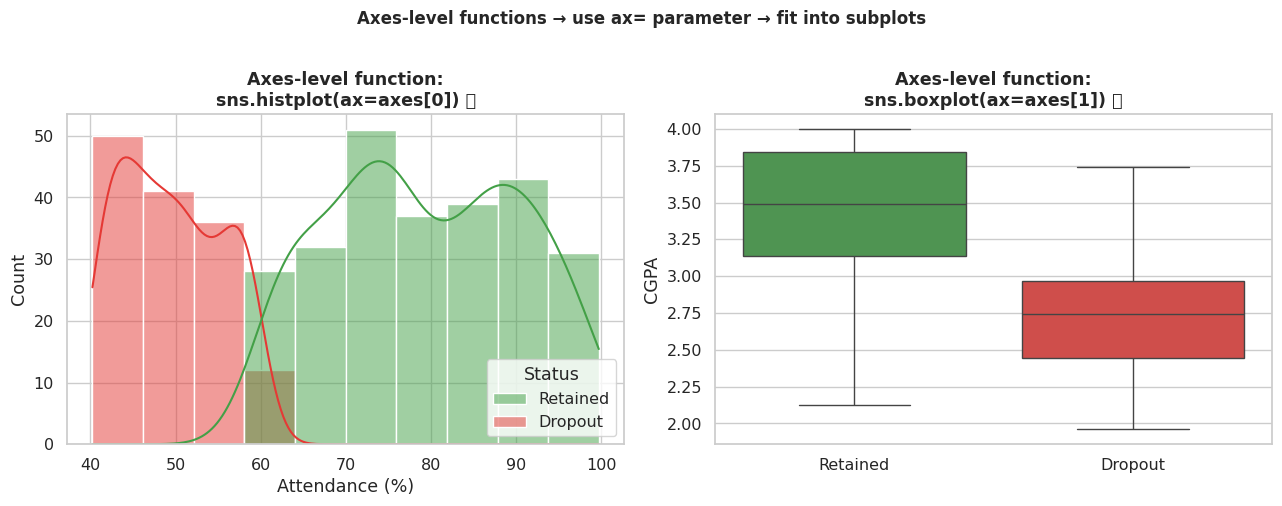


Figure-level functions (lmplot, pairplot, displot, catplot, FacetGrid):
  → They create their OWN figure. Do NOT use ax= with these.
  → Control size with: height=, aspect=
  → Returned object: FacetGrid — use g.figure.suptitle(), g.set_axis_labels()


In [23]:
# ── Figure-level vs Axes-level — the most confusing Seaborn concept ──
#
# Seaborn has TWO types of functions:
#
# AXES-LEVEL  (returns Axes) → histplot, scatterplot, boxplot, heatmap, etc.
#   - Use ax= to place them in a subplot grid
#   - All customization via ax.set_*() methods
#
# FIGURE-LEVEL (returns Grid) → displot, relplot, catplot, lmplot, pairplot, FacetGrid
#   - Creates its OWN figure — cannot use ax=
#   - Control size via height= and aspect=
#   - Customization via the grid object (g.set_axis_labels, g.set_titles)
#
# The rule: if you need the plot INSIDE a subplot grid, use the axes-level version.
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── AXES-LEVEL: histplot (can use ax=) ───────────────────
sns.histplot(data=df_eda, x='Attendance', hue='Status',
             multiple='layer', alpha=0.5, kde=True,
             palette={'Dropout':'#E53935', 'Retained':'#43A047'},
             ax=axes[0])        # ← specify exactly which panel to draw in
axes[0].set_title('Axes-level function:\nsns.histplot(ax=axes[0]) ✅',
                  fontweight='bold')
axes[0].set_xlabel('Attendance (%)')

# ── AXES-LEVEL: boxplot (can use ax=) ────────────────────
sns.boxplot(data=df_eda, x='Status', y='CGPA',
            hue='Status',
            palette={'Dropout':'#E53935', 'Retained':'#43A047'},
            legend=False,
            ax=axes[1])        # ← placed in second panel
axes[1].set_title('Axes-level function:\nsns.boxplot(ax=axes[1]) ✅',
                  fontweight='bold')
axes[1].set_xlabel('')

fig.suptitle('Axes-level functions → use ax= parameter → fit into subplots',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nFigure-level functions (lmplot, pairplot, displot, catplot, FacetGrid):")
print("  → They create their OWN figure. Do NOT use ax= with these.")
print("  → Control size with: height=, aspect=")
print("  → Returned object: FacetGrid — use g.figure.suptitle(), g.set_axis_labels()")


<a id='summary'></a>
## 12. Key Takeaways & Cheat Sheet

---

### 🏁 Functions You Will Actually Use

| Function | Task | Axes or Figure level? |
|----------|------|-----------------------|
| `sns.histplot()` | Distribution with optional KDE | Axes |
| `sns.kdeplot()` | Smooth density, compare groups | Axes |
| `sns.scatterplot()` | Relationships with hue/size/style | Axes |
| `sns.lineplot()` | Time series, auto CI band | Axes |
| `sns.barplot()` | Mean per category + CI | Axes |
| `sns.countplot()` | Count per category | Axes |
| `sns.boxplot()` | Quartiles + outliers | Axes |
| `sns.violinplot()` | Full distribution shape | Axes |
| `sns.stripplot()` | All data points (overlay) | Axes |
| `sns.heatmap()` | Correlation / confusion matrix | Axes |
| `sns.regplot()` | Scatter + regression line | Axes |
| `sns.pairplot()` | Full EDA grid in one line | **Figure** |
| `sns.lmplot()` | Regression across groups/facets | **Figure** |
| `sns.FacetGrid()` | Conditional subplot grid | **Figure** |

---

### 💡 Golden Rules

1. **`hue=`** is Seaborn's superpower — always try adding it first during EDA
2. **`pairplot(df, hue='target')`** is the first thing you run on any new dataset
3. **`heatmap(corr, annot=True)`** goes in every ML project — no exceptions
4. **Axes-level functions accept `ax=`** — use them inside subplot grids
5. **Figure-level functions (pairplot, lmplot, FacetGrid) create their own figure** — never pass `ax=`
6. **`set_theme()`** at the top of every notebook — one line, professional look everywhere
7. **After any Seaborn plot, use Matplotlib (`ax.set_*`, `ax.annotate`)** for fine-tuning
8. **`stripplot` on top of `boxplot`** is the publication-standard pattern — always consider it
9. **`fmt='d'` for integer heatmaps, `fmt='.2f'` for float, `fmt='.1%'` for percentages**
10. **`multiple='layer'` + `alpha=0.5`** for overlapping histograms — not `'stack'`

---

### 📊 EDA Workflow Checklist (copy this into every project)

```python
# 1. Load & inspect
df.shape, df.dtypes, df.isnull().sum(), df.describe()

# 2. Target distribution
sns.countplot(data=df, x='target')

# 3. Feature distributions
for col in numeric_cols:
    sns.histplot(data=df, x=col, hue='target', kde=True)

# 4. Correlation heatmap
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

# 5. Pairplot
sns.pairplot(df[top_features + ['target']], hue='target')

# 6. Box plots — feature vs target
for col in numeric_cols:
    sns.boxplot(data=df, x='target', y=col)

# 7. Confusion matrix (after training)
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
```

---

### 📖 Resources

- **Seaborn official gallery:** https://seaborn.pydata.org/examples/
- **API reference:** https://seaborn.pydata.org/api.html
- **Seaborn tutorial:** https://seaborn.pydata.org/tutorial.html

---

*Happy visualizing! 🎨*
